In [1]:
import numpy as np
import pickle
import torch
import os, sys
helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [2]:
# Import MC samples
scaler_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers"
mc_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/data"
signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal"

var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]

# Load MC samples

mc_events = np.load(f"{mc_path}/mc_events_chunk03.npz", allow_pickle=True)

with open(f"{scaler_path}/mc_scaler_chunk03.pkl","rb") as f:
    mc_scaler = pickle.load(f)

print(mc_events["mc_events_sr"].shape)


signal_samples = {}
signal_modes = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

# Import signal samples
all_columns = [
    "pT_j1", "eta_j1", "phi_j1",
    "pT_j2", "eta_j2", "phi_j2",
    "m_jj", "tau21_j1", "tau21_j2",
    "tau32_j1", "tau32_j2",
    "met", "phi_met", "min_dPhi", "ht"
]

# Find indices of desired variables
cols_to_use = [all_columns.index(v) for v in var_names]

def sr_mask(events):
    ht = events[:,0]
    met = events[:,1]
    # Apply SR cuts
    mask = (ht > 600) & (met > 600)
    return mask

for mode in signal_modes:
    signal_data = np.loadtxt(f"{signal_path}/{mode}_events.txt", skiprows=1, usecols=cols_to_use)
    sig_mask = sr_mask(signal_data)
    signal_samples[mode] = mc_scaler.transform(signal_data[sig_mask])
    print(f"Loaded signal mode {mode} with shape: {signal_data.shape}")
    np.savez("")

(46968, 7)
Loaded signal mode 1000_2 with shape: (5347, 7)
Loaded signal mode 1000_4 with shape: (6237, 7)
Loaded signal mode 1000_6 with shape: (6997, 7)
Loaded signal mode 1000_8 with shape: (7801, 7)
Loaded signal mode 2000_2 with shape: (3968, 7)
Loaded signal mode 2000_4 with shape: (4717, 7)
Loaded signal mode 2000_6 with shape: (5466, 7)
Loaded signal mode 2000_8 with shape: (6093, 7)
Loaded signal mode 3000_2 with shape: (1769, 7)
Loaded signal mode 3000_4 with shape: (2123, 7)
Loaded signal mode 3000_6 with shape: (2405, 7)
Loaded signal mode 3000_8 with shape: (2847, 7)


In [3]:
mixed_data = {}
for mode in signal_modes:
    mixed_data[mode] = np.vstack((mc_events["mc_events_sr"], signal_samples[mode]))
    print(f"Mixed data for mode {mode} has shape: {mixed_data[mode].shape}")

Mixed data for mode 1000_2 has shape: (46991, 7)
Mixed data for mode 1000_4 has shape: (46998, 7)
Mixed data for mode 1000_6 has shape: (46988, 7)
Mixed data for mode 1000_8 has shape: (47009, 7)
Mixed data for mode 2000_2 has shape: (47376, 7)
Mixed data for mode 2000_4 has shape: (47622, 7)
Mixed data for mode 2000_6 has shape: (47894, 7)
Mixed data for mode 2000_8 has shape: (48214, 7)
Mixed data for mode 3000_2 has shape: (47497, 7)
Mixed data for mode 3000_4 has shape: (47699, 7)
Mixed data for mode 3000_6 has shape: (47914, 7)
Mixed data for mode 3000_8 has shape: (48224, 7)


In [4]:
x_test = {}
y_test = {}

n_bkg = mc_events["mc_events_sr"].shape[0]

for mode in signal_modes:
    n_sig = signal_samples[mode].shape[0]

    # x_test = mixed features (already scaled)
    x_test[mode] = mixed_data[mode]

    # y_test = 0 for background, 1 for signal
    y_bkg = np.zeros(n_bkg)
    y_sig = np.ones(n_sig)
    y_test[mode] = np.concatenate((y_bkg, y_sig))

    print(f"Mode {mode}: x_test {x_test[mode].shape}, y_test {y_test[mode].shape}, signal fraction = {n_sig / (n_sig + n_bkg):.3f}")


Mode 1000_2: x_test (46991, 7), y_test (46991,), signal fraction = 0.000
Mode 1000_4: x_test (46998, 7), y_test (46998,), signal fraction = 0.001
Mode 1000_6: x_test (46988, 7), y_test (46988,), signal fraction = 0.000
Mode 1000_8: x_test (47009, 7), y_test (47009,), signal fraction = 0.001
Mode 2000_2: x_test (47376, 7), y_test (47376,), signal fraction = 0.009
Mode 2000_4: x_test (47622, 7), y_test (47622,), signal fraction = 0.014
Mode 2000_6: x_test (47894, 7), y_test (47894,), signal fraction = 0.019
Mode 2000_8: x_test (48214, 7), y_test (48214,), signal fraction = 0.026
Mode 3000_2: x_test (47497, 7), y_test (47497,), signal fraction = 0.011
Mode 3000_4: x_test (47699, 7), y_test (47699,), signal fraction = 0.015
Mode 3000_6: x_test (47914, 7), y_test (47914,), signal fraction = 0.020
Mode 3000_8: x_test (48224, 7), y_test (48224,), signal fraction = 0.026


In [5]:
# Load Trained Machine Learning models

import glob

base_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr"

# Datasets
datasets = [f"Data0{i}" for i in range(1, 6)]

# Initialize dicts
generate_models_paths = {}
reweight_models_paths = {}

for d in datasets:
    # Collect .pt files belonging to this dataset
    gen_models = sorted(glob.glob(f"{base_path}/model_generate_SR_{d}_MC*run*.pt"))
    rew_models = sorted(glob.glob(f"{base_path}/model_reweight_SR_{d}_MC*run*.pt"))

    generate_models_paths[d] = gen_models
    reweight_models_paths[d] = rew_models

    print(f"{d}: {len(gen_models)} generate models, {len(rew_models)} reweight models")

# Optional sanity check
# print("\nExample:")
# print("Data01 generate models:", generate_models_paths["Data01"][:3])
# print("Data01 reweight models:", reweight_models_paths["Data01"][:3])

Data01: 20 generate models, 20 reweight models
Data02: 20 generate models, 20 reweight models
Data03: 20 generate models, 20 reweight models
Data04: 20 generate models, 20 reweight models
Data05: 20 generate models, 20 reweight models


In [6]:
print("mc_events_sr shape:", mc_events["mc_events_sr"].shape)
for mode in signal_modes:
    print(mode, "signal shape:", signal_samples[mode].shape, "mixed:", mixed_data[mode].shape)
    print(" label counts:", np.unique(y_test[mode], return_counts=True))
    print(" first 5 y:", y_test[mode][:10])
    # print(" example features (first row):", x_test[mode][0])

mc_events_sr shape: (46968, 7)
1000_2 signal shape: (23, 7) mixed: (46991, 7)
 label counts: (array([0., 1.]), array([46968,    23]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_4 signal shape: (30, 7) mixed: (46998, 7)
 label counts: (array([0., 1.]), array([46968,    30]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_6 signal shape: (20, 7) mixed: (46988, 7)
 label counts: (array([0., 1.]), array([46968,    20]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1000_8 signal shape: (41, 7) mixed: (47009, 7)
 label counts: (array([0., 1.]), array([46968,    41]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_2 signal shape: (408, 7) mixed: (47376, 7)
 label counts: (array([0., 1.]), array([46968,   408]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_4 signal shape: (654, 7) mixed: (47622, 7)
 label counts: (array([0., 1.]), array([46968,   654]))
 first 5 y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
2000_6 signal shape: (926, 7) mixed: (47894, 7)
 label counts: (array([0., 1.]), arra


=== Evaluating models for Data01 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4053, MaxSIC = 1.0010
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4162, MaxSIC = 1.0012
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4002, MaxSIC = 1.0017
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4025, MaxSIC = 1.0016
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt


/home/aegis/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


      AUC = 0.4108, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4080, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4044, MaxSIC = 1.0010
   ▶️ Run 08: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run15.pt
      AUC = 0.4041, MaxSIC = 1.0014
   ▶️ Run 09: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run16.pt
      AUC = 0.4045, MaxSIC = 1.0011
   ▶️ Run 10: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run17.pt
      AUC = 0.4002, MaxSIC = 1.0019
   ▶️ Run 11: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run18.pt
      AUC = 0.4168, MaxSIC = 1.0012
   ▶️ Run 12: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run19.pt
      AUC = 0.4109, 

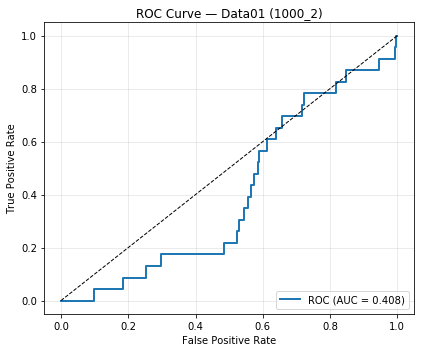

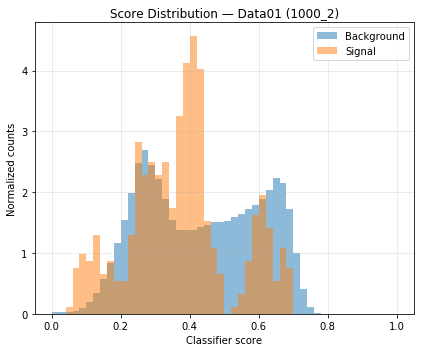


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.3350, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.3478, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.3378, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.3400, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.3456, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.3453, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.3350, MaxSIC = 

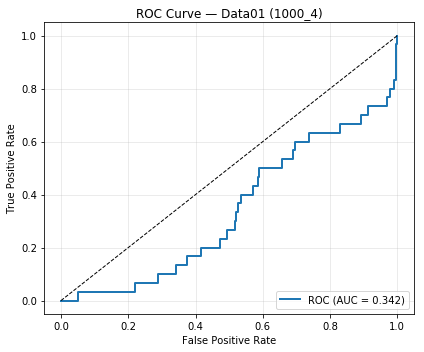

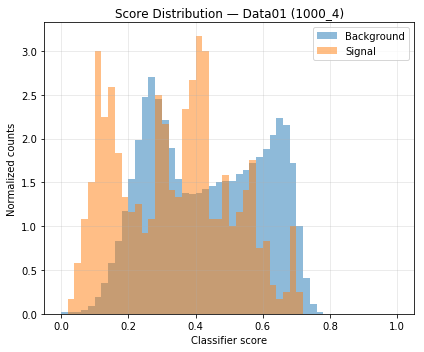


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.4094, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.4014, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.4004, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.4110, MaxSIC = 1.0022
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.4187, MaxSIC = 1.0300
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4173, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.4077, MaxSIC = 

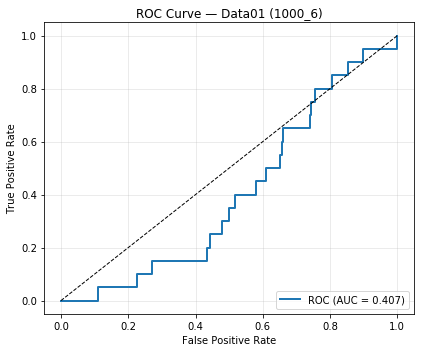

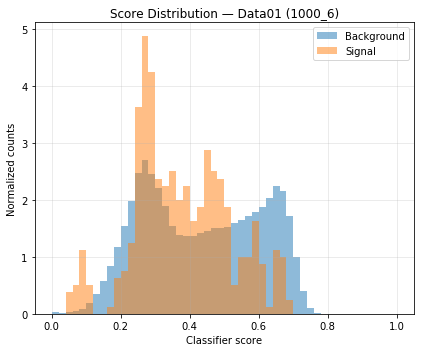


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.3925, MaxSIC = 1.0011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.3930, MaxSIC = 1.0013
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.3909, MaxSIC = 1.0018
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.3990, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.3961, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.4041, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.3970, MaxSIC = 

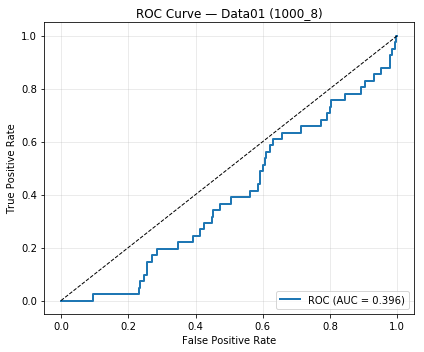

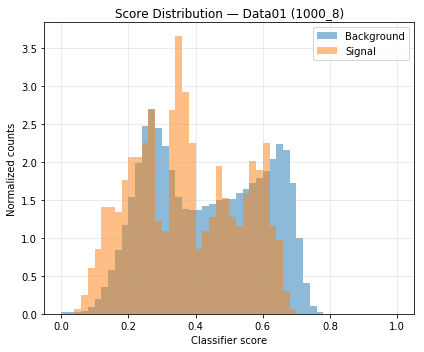


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.1492, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.1487, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.1470, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.1462, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.1439, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1501, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.1429, MaxSIC = 

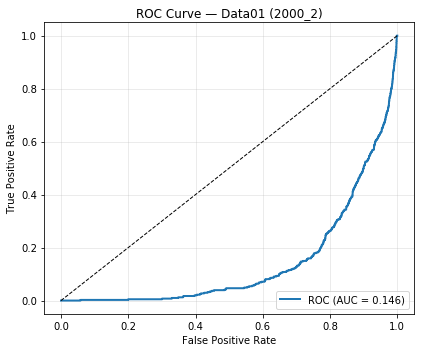

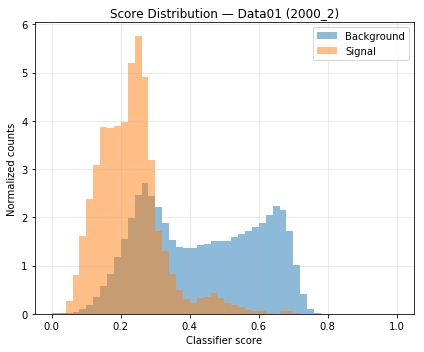


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.1476, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.1456, MaxSIC = 1.0009
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.1448, MaxSIC = 1.0011
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.1448, MaxSIC = 1.0010
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.1409, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1472, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.1420, MaxSIC = 

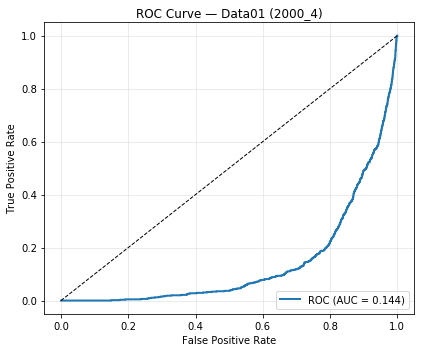

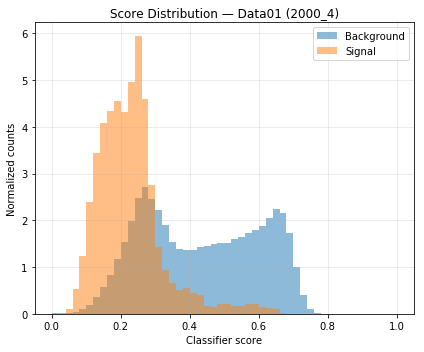


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.1452, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.1458, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.1453, MaxSIC = 1.0010
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.1441, MaxSIC = 1.0005
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.1418, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1462, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.1438, MaxSIC = 

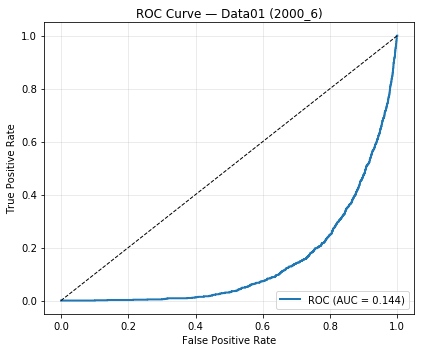

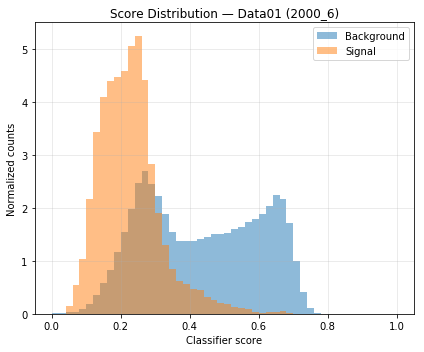


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.1501, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.1523, MaxSIC = 1.0006
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.1514, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.1517, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.1500, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1522, MaxSIC = 1.0004
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.1500, MaxSIC = 

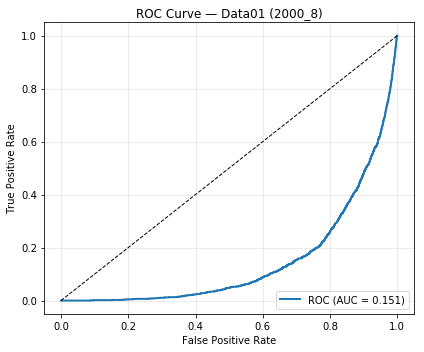

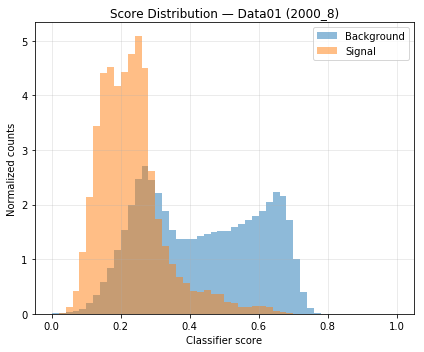


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.0944, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.0898, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.0824, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.0861, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.0933, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1054, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.0979, MaxSIC = 

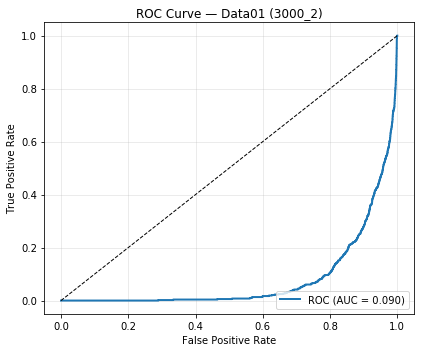

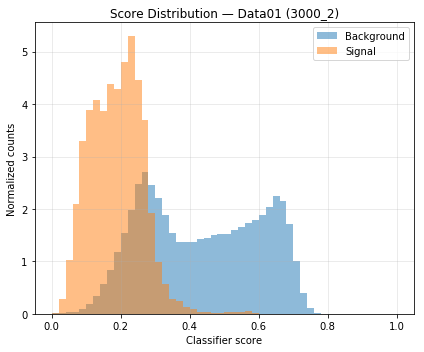


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.0861, MaxSIC = 1.0002
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.0828, MaxSIC = 1.0005
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.0756, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.0807, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.0871, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1012, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.0930, MaxSIC = 

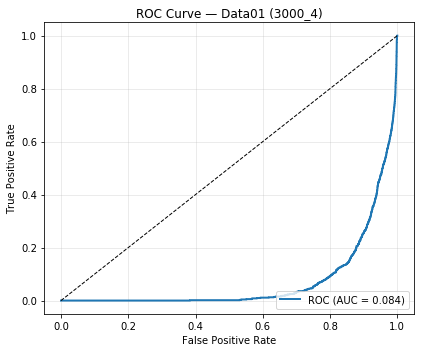

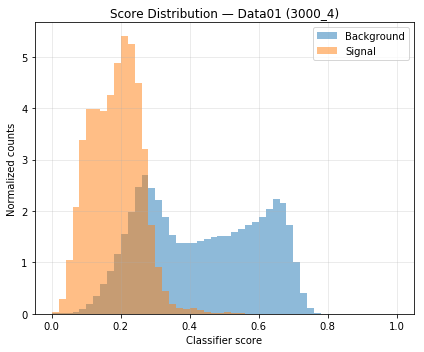


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.0863, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.0835, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.0777, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.0815, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.0865, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1009, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.0936, MaxSIC = 

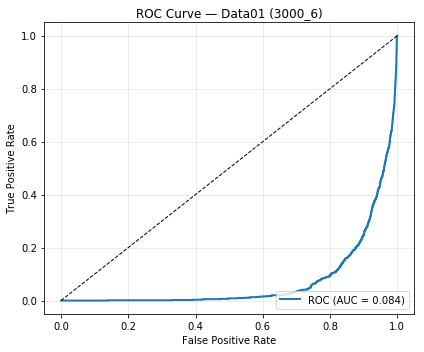

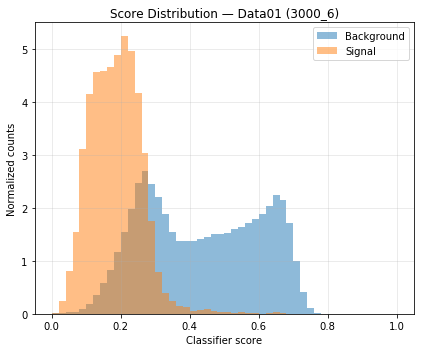


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run0.pt
      AUC = 0.0907, MaxSIC = 1.0002
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run1.pt
      AUC = 0.0888, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run10.pt
      AUC = 0.0826, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run11.pt
      AUC = 0.0864, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run12.pt
      AUC = 0.0931, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run13.pt
      AUC = 0.1081, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data01_MC02_run14.pt
      AUC = 0.0985, MaxSIC = 

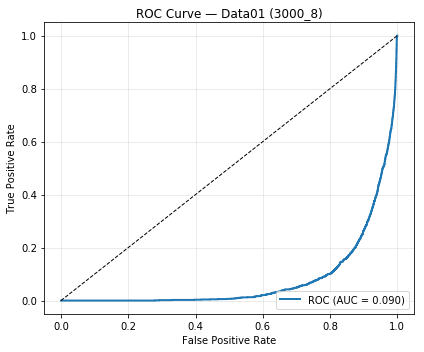

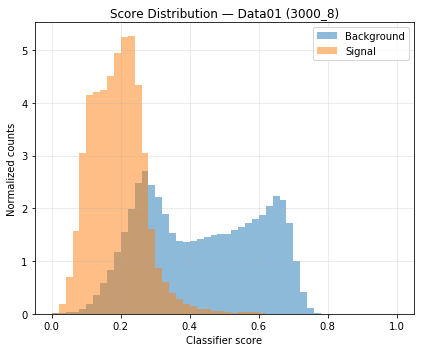


=== Evaluating models for Data02 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4036, MaxSIC = 1.0011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4162, MaxSIC = 1.0012
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4002, MaxSIC = 1.0017
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4025, MaxSIC = 1.0016
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4108, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4080, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_

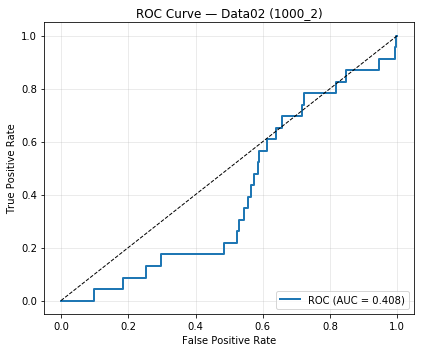

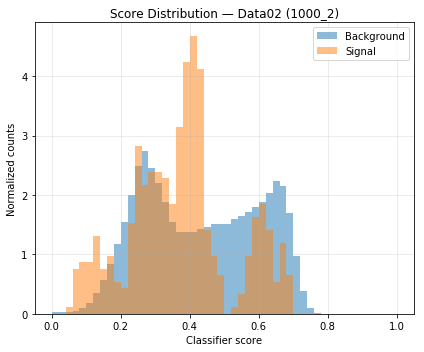


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.3470, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.3478, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.3378, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.3400, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.3456, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.3453, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.3350, MaxSIC = 

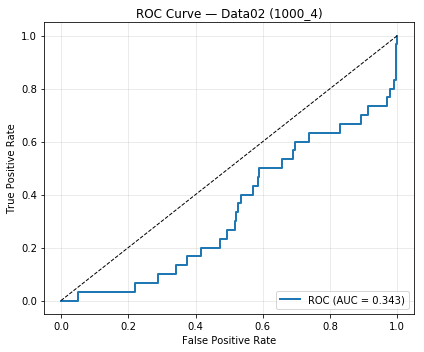

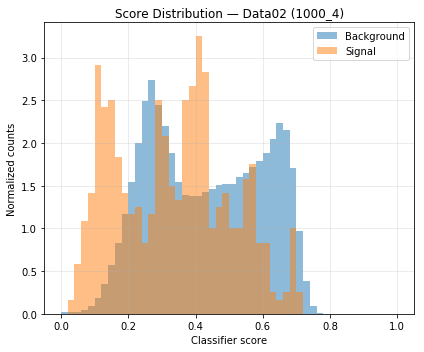


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.4097, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.4014, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.4004, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.4110, MaxSIC = 1.0022
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.4187, MaxSIC = 1.0300
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4173, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.4077, MaxSIC = 

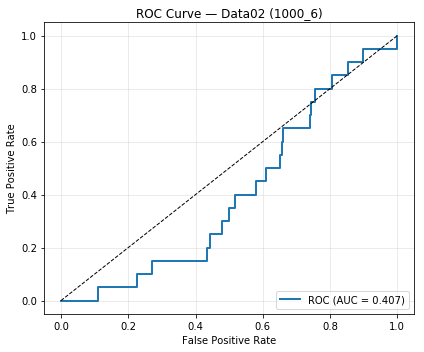

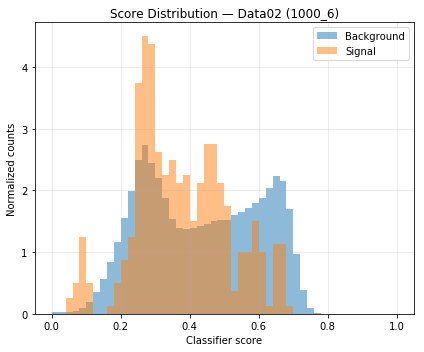


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.3995, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.3930, MaxSIC = 1.0013
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.3909, MaxSIC = 1.0018
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.3990, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.3961, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.4041, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.3970, MaxSIC = 

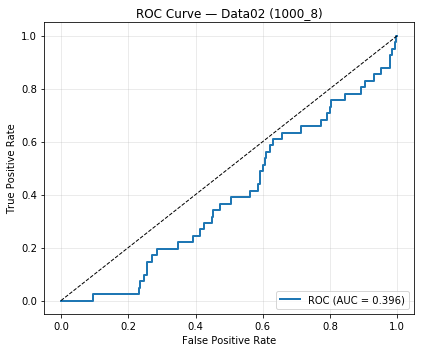

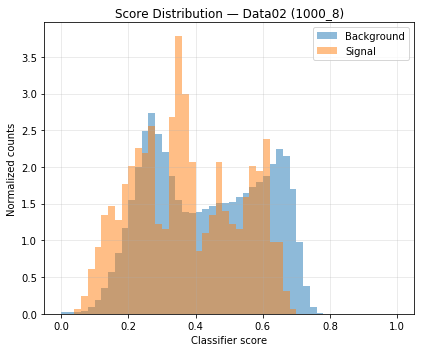


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.1501, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.1487, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.1470, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.1462, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.1439, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1501, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.1429, MaxSIC = 

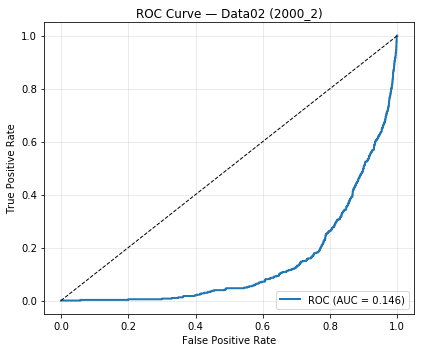

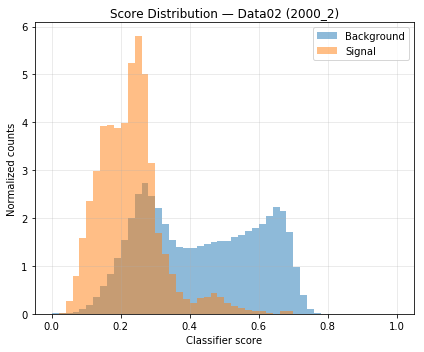


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.1477, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.1456, MaxSIC = 1.0009
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.1448, MaxSIC = 1.0011
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.1448, MaxSIC = 1.0010
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.1409, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1472, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.1420, MaxSIC = 

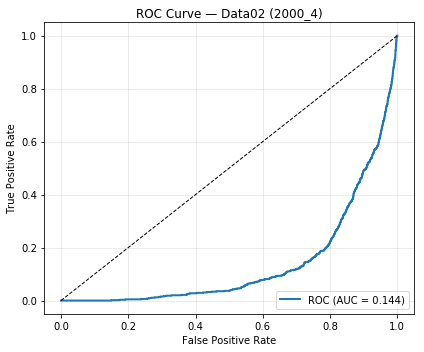

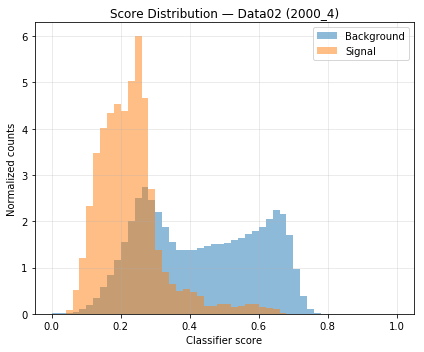


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.1486, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.1458, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.1453, MaxSIC = 1.0010
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.1441, MaxSIC = 1.0005
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.1418, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1462, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.1438, MaxSIC = 

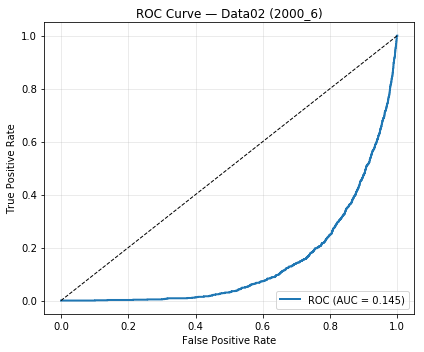

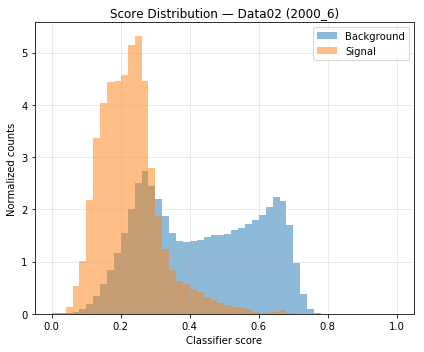


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.1542, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.1523, MaxSIC = 1.0006
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.1514, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.1517, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.1500, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1522, MaxSIC = 1.0004
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.1500, MaxSIC = 

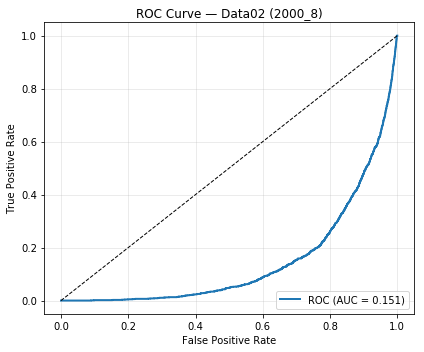

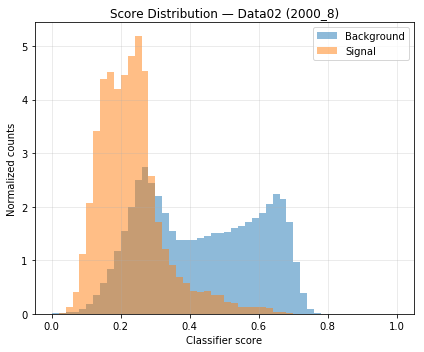


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.0935, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.0898, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.0824, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.0861, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.0933, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1054, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.0979, MaxSIC = 

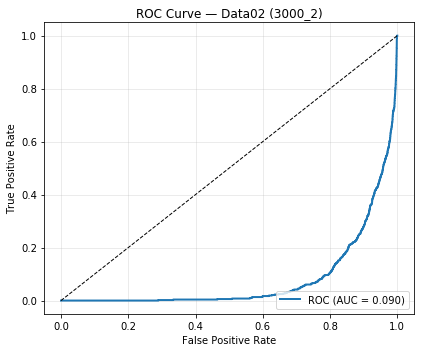

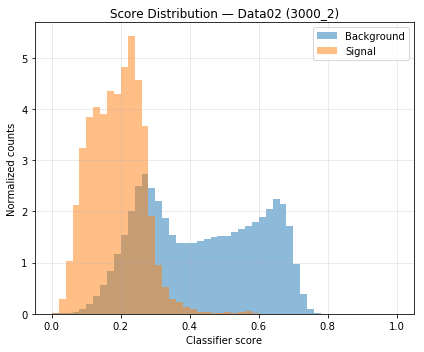


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.0879, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.0828, MaxSIC = 1.0005
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.0756, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.0807, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.0871, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1012, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.0930, MaxSIC = 

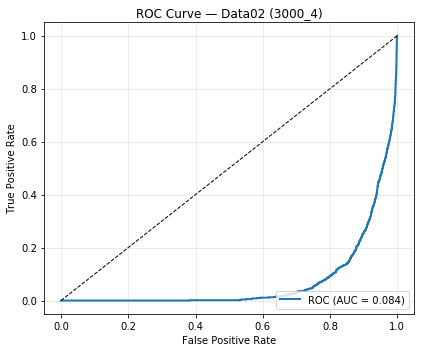

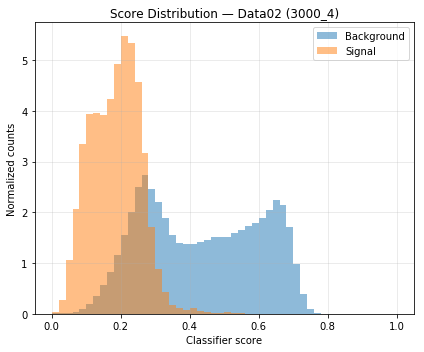


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.0886, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.0835, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.0777, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.0815, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.0865, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1009, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.0936, MaxSIC = 

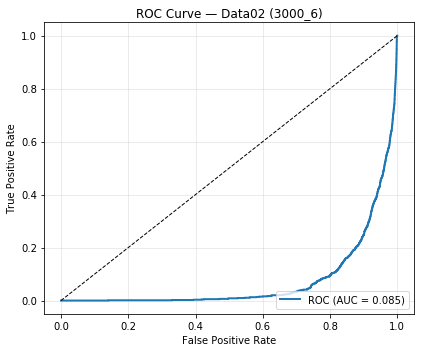

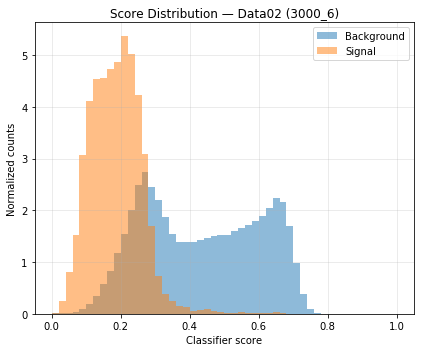


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run0.pt
      AUC = 0.0940, MaxSIC = 1.0004
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run1.pt
      AUC = 0.0888, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run10.pt
      AUC = 0.0826, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run11.pt
      AUC = 0.0864, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run12.pt
      AUC = 0.0931, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run13.pt
      AUC = 0.1081, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data02_MC02_run14.pt
      AUC = 0.0985, MaxSIC = 

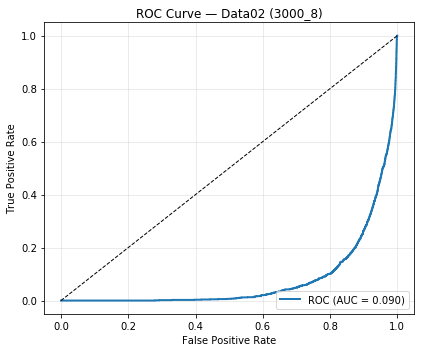

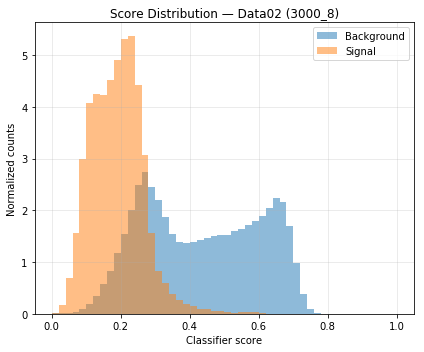


=== Evaluating models for Data03 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4036, MaxSIC = 1.0011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4162, MaxSIC = 1.0012
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4002, MaxSIC = 1.0017
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4025, MaxSIC = 1.0016
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4108, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4080, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_

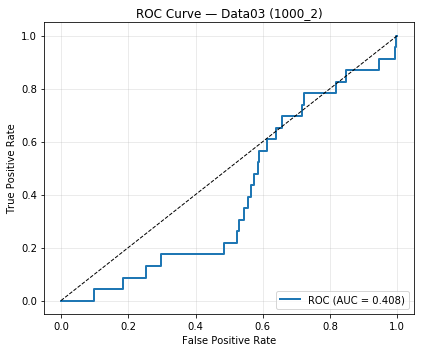

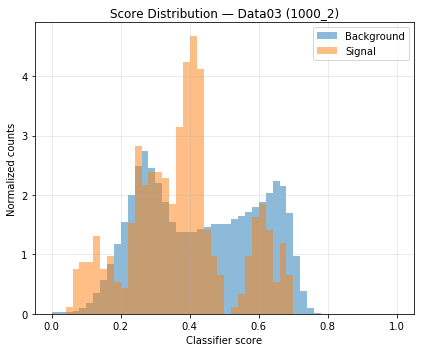


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.3470, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.3478, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.3378, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.3400, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.3456, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.3453, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.3350, MaxSIC = 

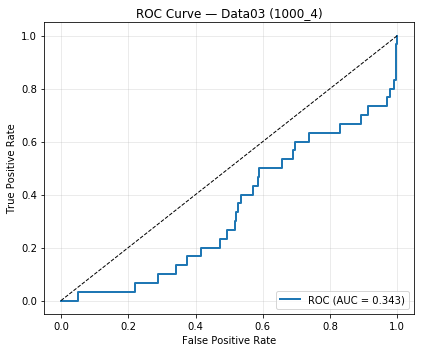

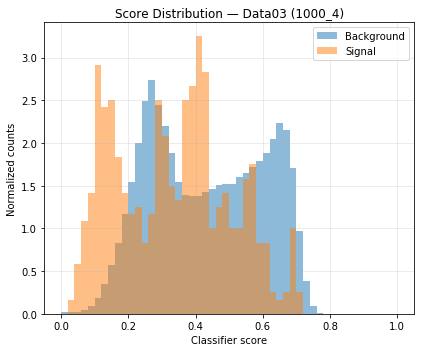


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.4097, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.4014, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.4004, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.4110, MaxSIC = 1.0022
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.4187, MaxSIC = 1.0300
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4173, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.4077, MaxSIC = 

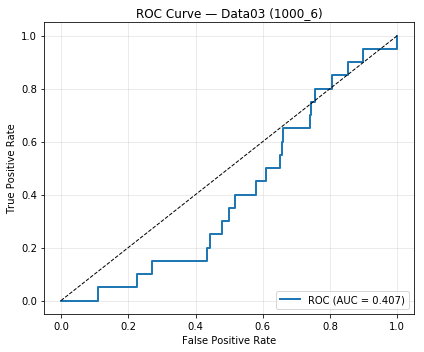

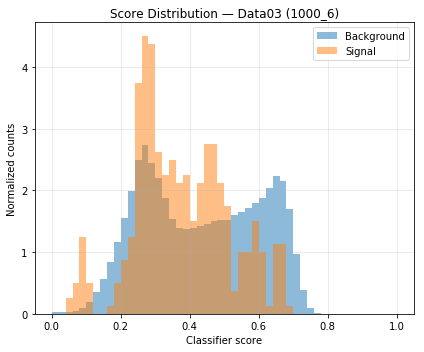


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.3995, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.3930, MaxSIC = 1.0013
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.3909, MaxSIC = 1.0018
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.3990, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.3961, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.4041, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.3970, MaxSIC = 

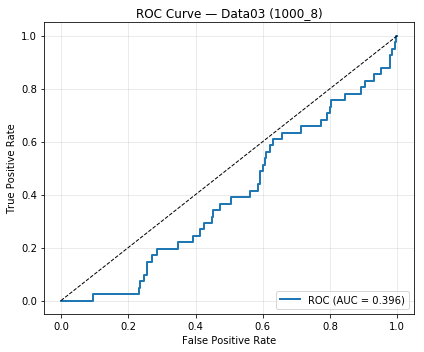

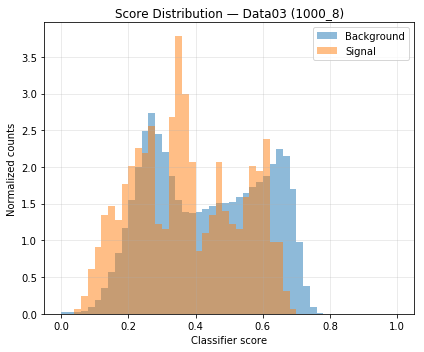


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.1501, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.1487, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.1470, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.1462, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.1439, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1501, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.1429, MaxSIC = 

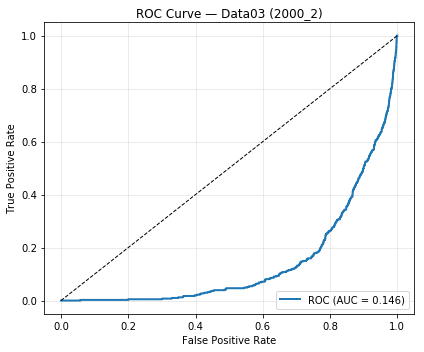

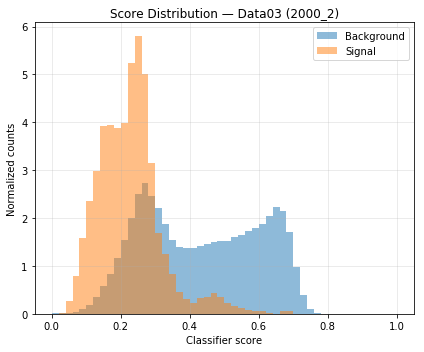


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.1477, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.1456, MaxSIC = 1.0009
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.1448, MaxSIC = 1.0011
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.1448, MaxSIC = 1.0010
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.1409, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1472, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.1420, MaxSIC = 

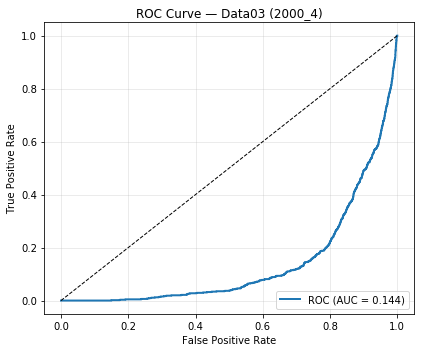

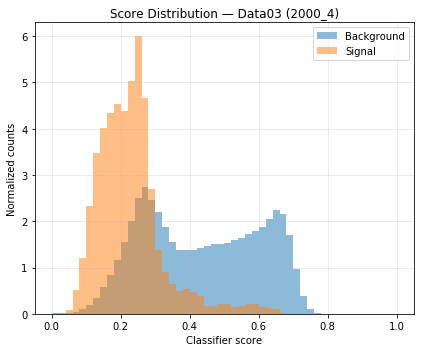


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.1486, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.1458, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.1453, MaxSIC = 1.0010
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.1441, MaxSIC = 1.0005
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.1418, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1462, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.1438, MaxSIC = 

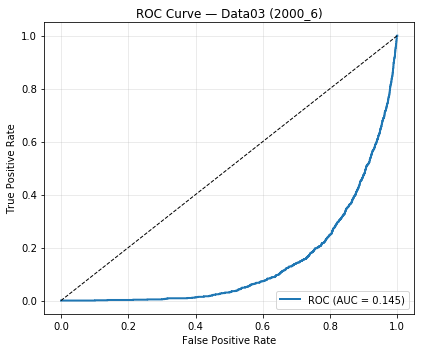

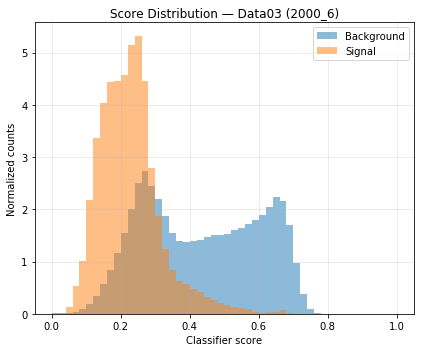


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.1542, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.1523, MaxSIC = 1.0006
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.1514, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.1517, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.1500, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1522, MaxSIC = 1.0004
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.1500, MaxSIC = 

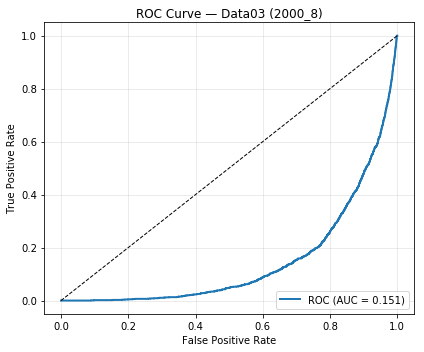

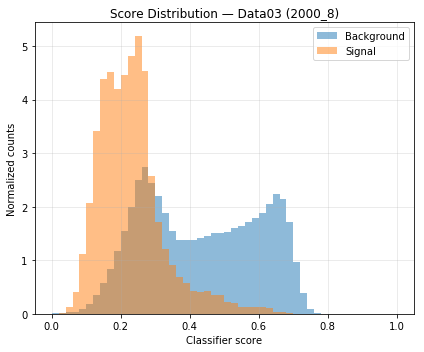


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.0935, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.0898, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.0824, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.0861, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.0933, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1054, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.0979, MaxSIC = 

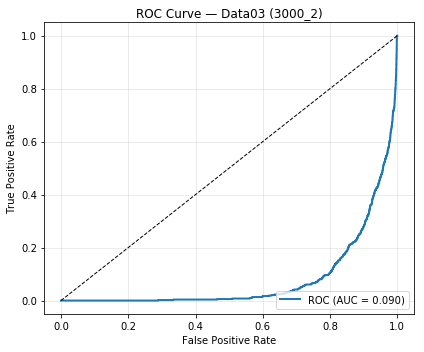

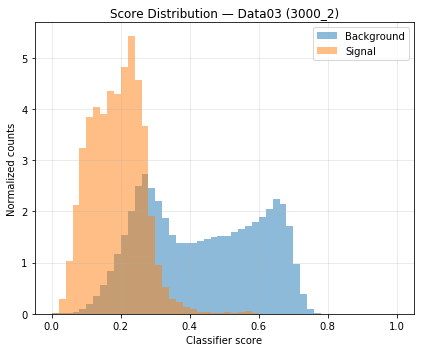


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.0879, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.0828, MaxSIC = 1.0005
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.0756, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.0807, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.0871, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1012, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.0930, MaxSIC = 

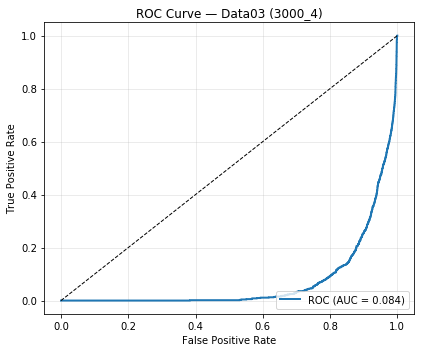

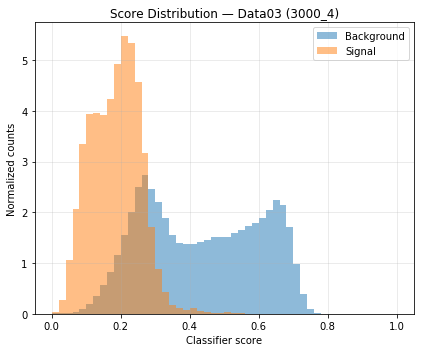


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.0886, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.0835, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.0777, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.0815, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.0865, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1009, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.0936, MaxSIC = 

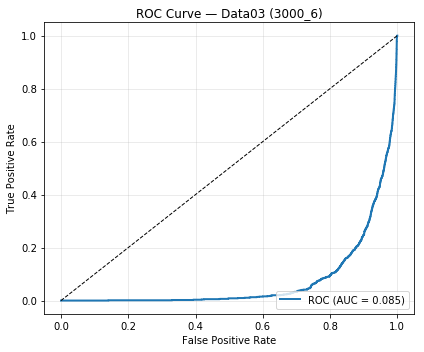

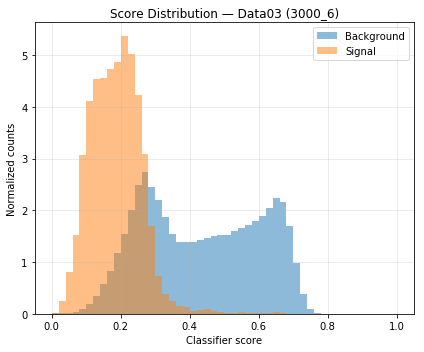


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run0.pt
      AUC = 0.0940, MaxSIC = 1.0004
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run1.pt
      AUC = 0.0888, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run10.pt
      AUC = 0.0826, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run11.pt
      AUC = 0.0864, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run12.pt
      AUC = 0.0931, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run13.pt
      AUC = 0.1081, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data03_MC02_run14.pt
      AUC = 0.0985, MaxSIC = 

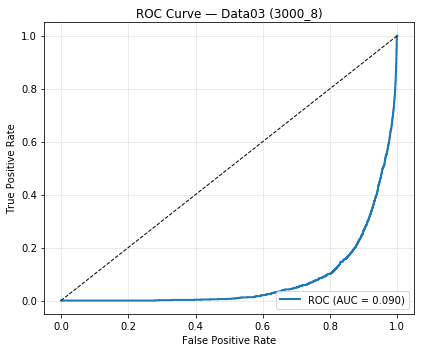

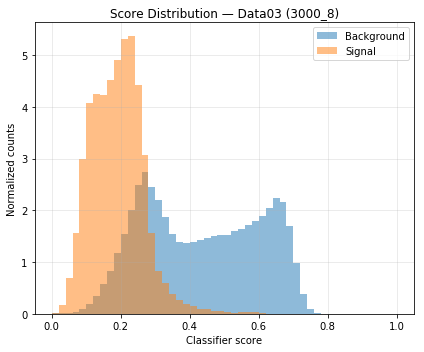


=== Evaluating models for Data04 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4036, MaxSIC = 1.0011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4162, MaxSIC = 1.0012
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4002, MaxSIC = 1.0017
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4025, MaxSIC = 1.0016
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4108, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4080, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_

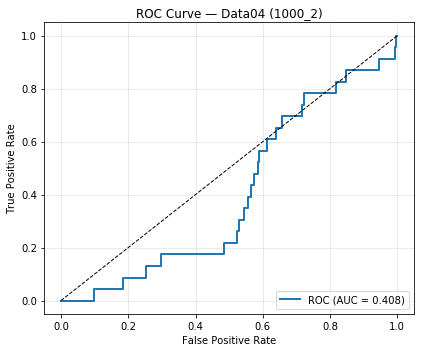

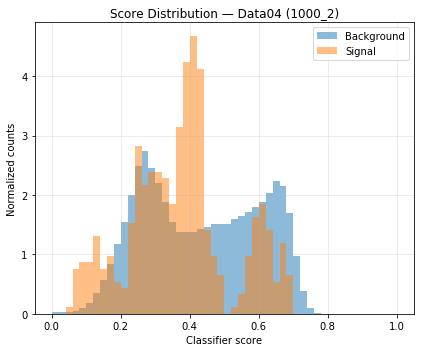


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.3470, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.3478, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.3378, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.3400, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.3456, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.3453, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.3350, MaxSIC = 

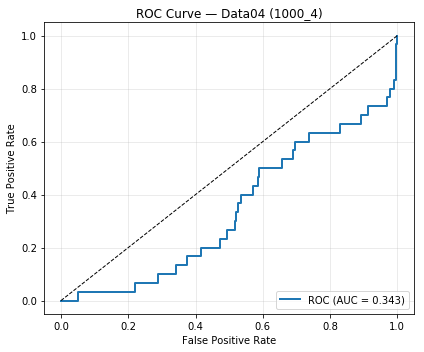

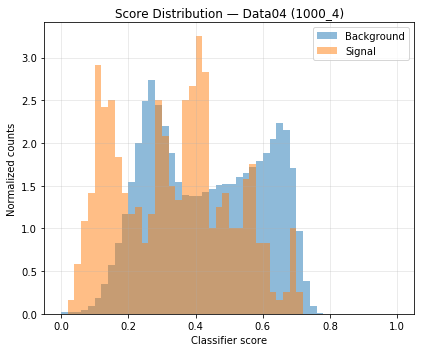


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.4097, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.4014, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.4004, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.4110, MaxSIC = 1.0022
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.4187, MaxSIC = 1.0300
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4173, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.4077, MaxSIC = 

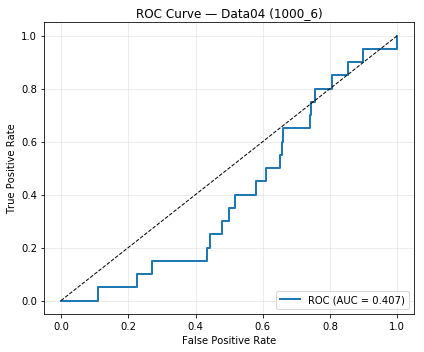

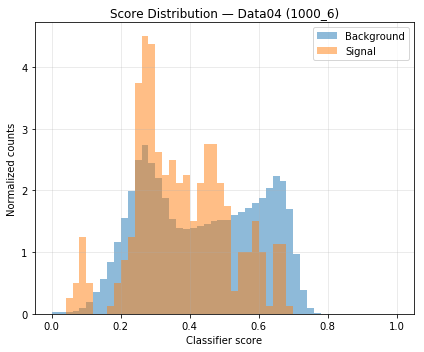


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.3995, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.3930, MaxSIC = 1.0013
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.3909, MaxSIC = 1.0018
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.3990, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.3961, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.4041, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.3970, MaxSIC = 

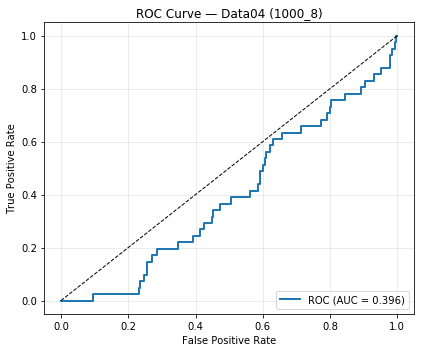

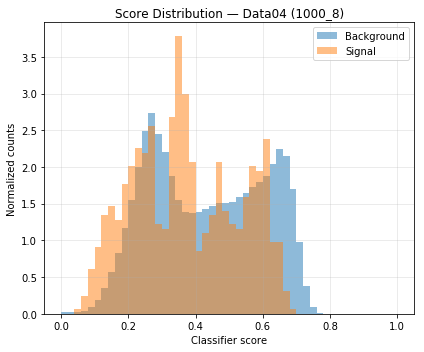


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.1501, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.1487, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.1470, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.1462, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.1439, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1501, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.1429, MaxSIC = 

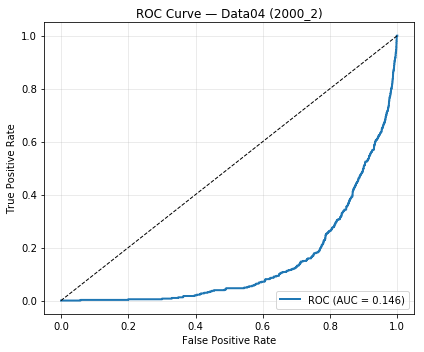

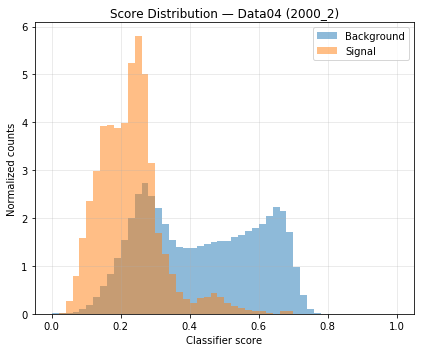


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.1477, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.1456, MaxSIC = 1.0009
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.1448, MaxSIC = 1.0011
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.1448, MaxSIC = 1.0010
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.1409, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1472, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.1420, MaxSIC = 

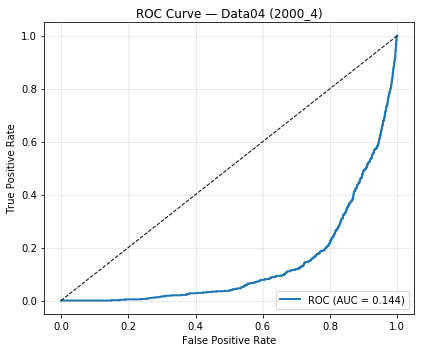

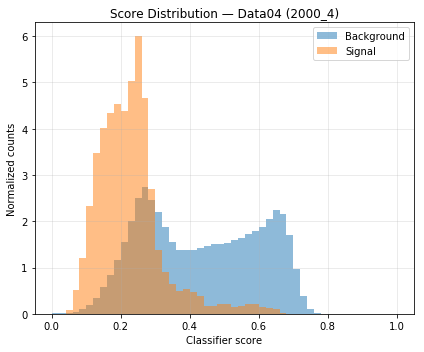


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.1486, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.1458, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.1453, MaxSIC = 1.0010
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.1441, MaxSIC = 1.0005
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.1418, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1462, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.1438, MaxSIC = 

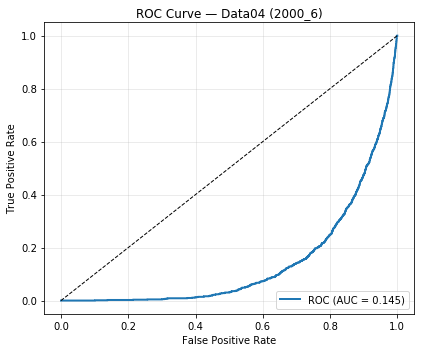

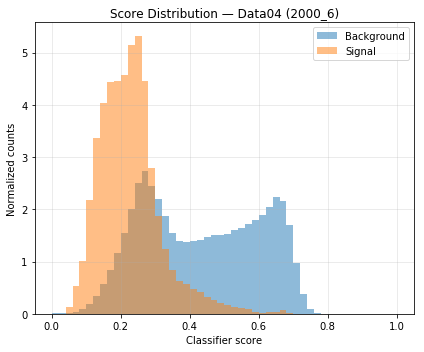


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.1542, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.1523, MaxSIC = 1.0006
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.1514, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.1517, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.1500, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1522, MaxSIC = 1.0004
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.1500, MaxSIC = 

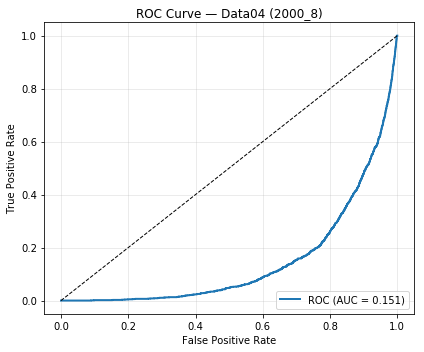

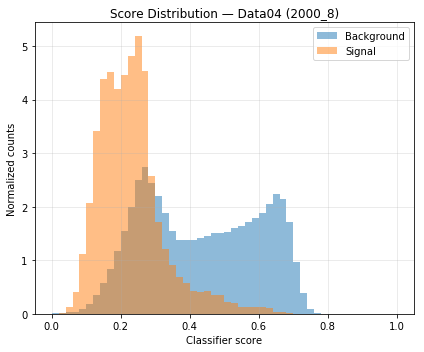


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.0935, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.0898, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.0824, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.0861, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.0933, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1054, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.0979, MaxSIC = 

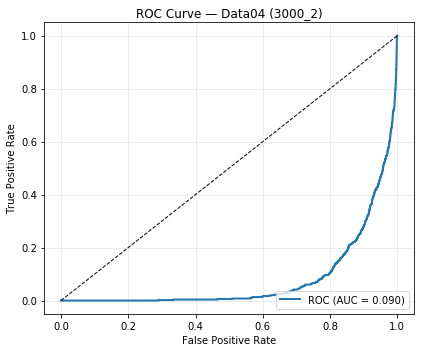

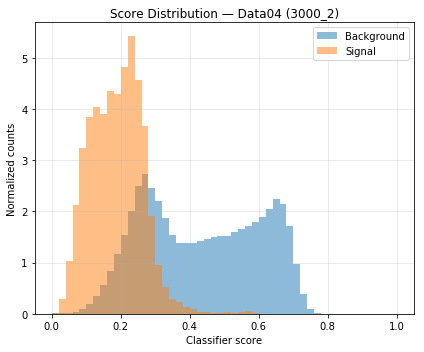


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.0879, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.0828, MaxSIC = 1.0005
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.0756, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.0807, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.0871, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1012, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.0930, MaxSIC = 

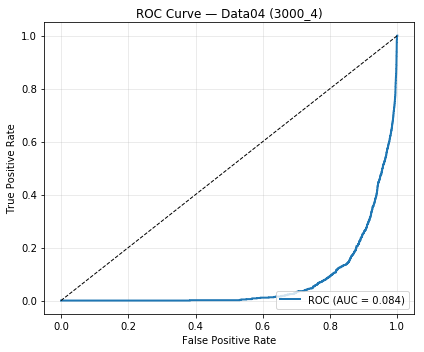

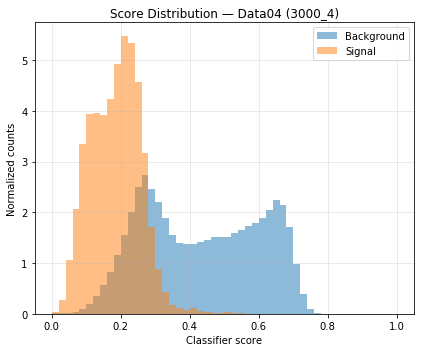


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.0886, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.0835, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.0777, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.0815, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.0865, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1009, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.0936, MaxSIC = 

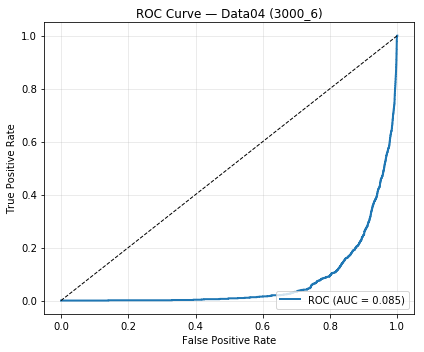

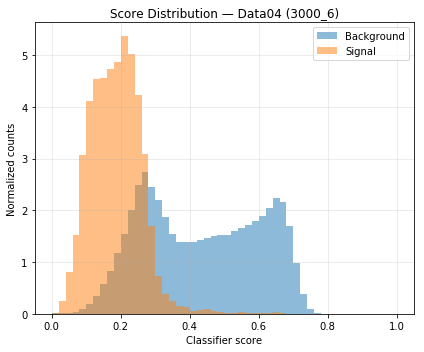


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run0.pt
      AUC = 0.0940, MaxSIC = 1.0004
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run1.pt
      AUC = 0.0888, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run10.pt
      AUC = 0.0826, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run11.pt
      AUC = 0.0864, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run12.pt
      AUC = 0.0931, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run13.pt
      AUC = 0.1081, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data04_MC02_run14.pt
      AUC = 0.0985, MaxSIC = 

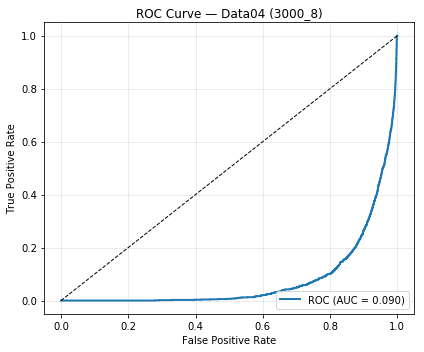

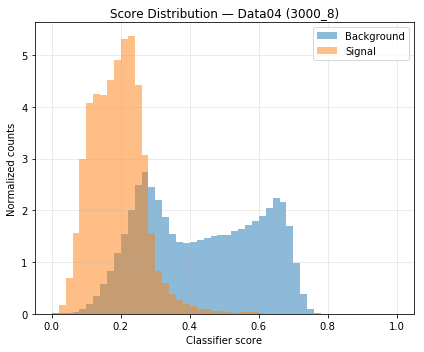


=== Evaluating models for Data05 ===

--- Signal mode: 1000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4036, MaxSIC = 1.0011
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4162, MaxSIC = 1.0012
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4002, MaxSIC = 1.0017
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4025, MaxSIC = 1.0016
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4108, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4080, MaxSIC = 1.0009
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_

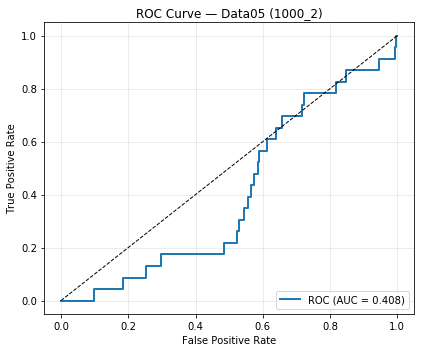

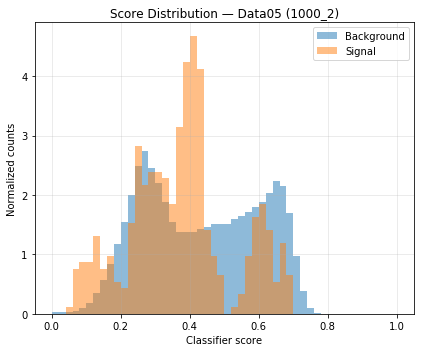


--- Signal mode: 1000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.3470, MaxSIC = 1.0006
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.3478, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.3378, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.3400, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.3456, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.3453, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.3350, MaxSIC = 

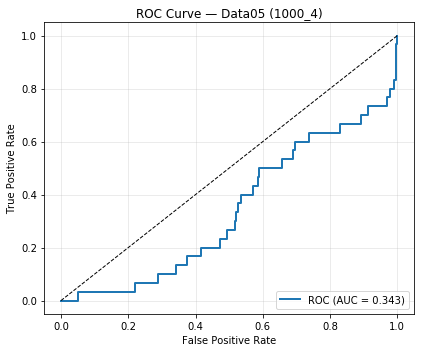

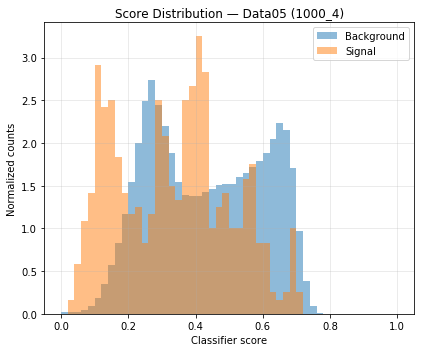


--- Signal mode: 1000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.4097, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.4014, MaxSIC = 1.0016
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.4004, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.4110, MaxSIC = 1.0022
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.4187, MaxSIC = 1.0300
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4173, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.4077, MaxSIC = 

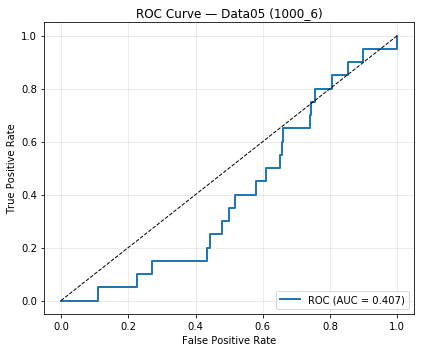

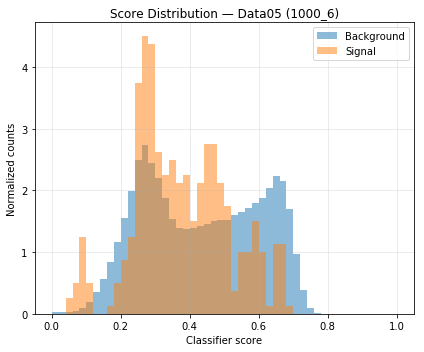


--- Signal mode: 1000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.3995, MaxSIC = 1.0014
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.3930, MaxSIC = 1.0013
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.3909, MaxSIC = 1.0018
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.3990, MaxSIC = 1.0019
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.3961, MaxSIC = 1.0008
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.4041, MaxSIC = 1.0011
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.3970, MaxSIC = 

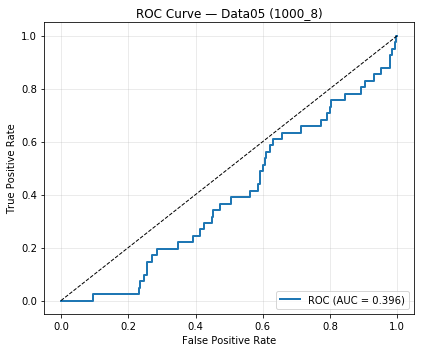

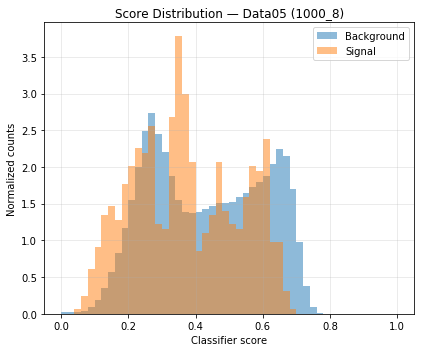


--- Signal mode: 2000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.1501, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.1487, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.1470, MaxSIC = 1.0012
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.1462, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.1439, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1501, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.1429, MaxSIC = 

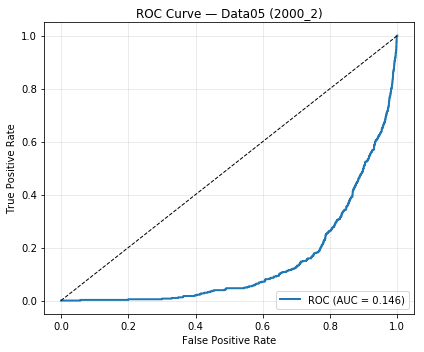

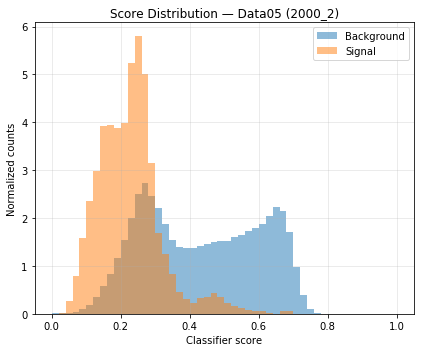


--- Signal mode: 2000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.1477, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.1456, MaxSIC = 1.0009
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.1448, MaxSIC = 1.0011
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.1448, MaxSIC = 1.0010
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.1409, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1472, MaxSIC = 1.0006
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.1420, MaxSIC = 

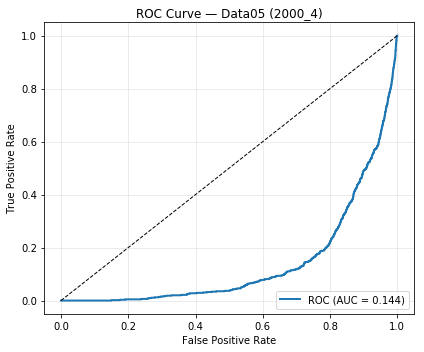

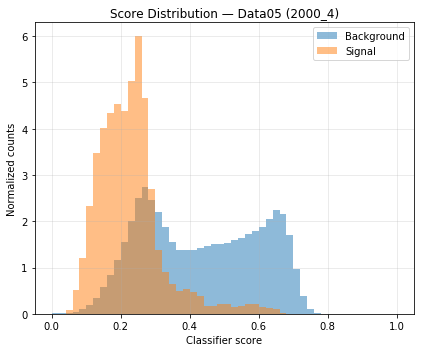


--- Signal mode: 2000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.1486, MaxSIC = 1.0008
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.1458, MaxSIC = 1.0008
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.1453, MaxSIC = 1.0010
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.1441, MaxSIC = 1.0005
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.1418, MaxSIC = 1.0007
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1462, MaxSIC = 1.0005
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.1438, MaxSIC = 

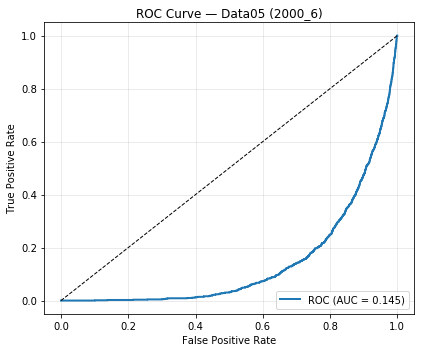

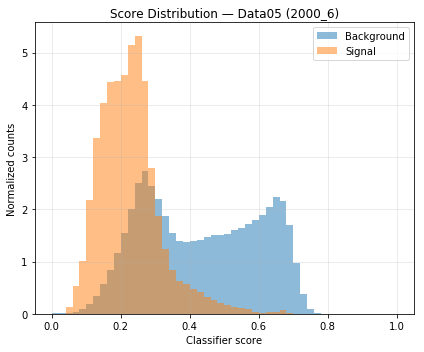


--- Signal mode: 2000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.1542, MaxSIC = 1.0005
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.1523, MaxSIC = 1.0006
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.1514, MaxSIC = 1.0008
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.1517, MaxSIC = 1.0007
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.1500, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1522, MaxSIC = 1.0004
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.1500, MaxSIC = 

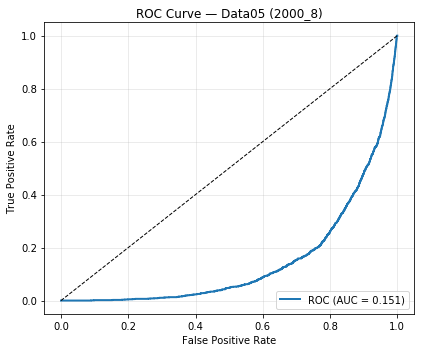

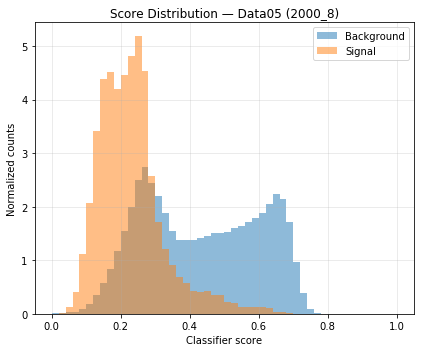


--- Signal mode: 3000_2 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.0935, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.0898, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.0824, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.0861, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.0933, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1054, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.0979, MaxSIC = 

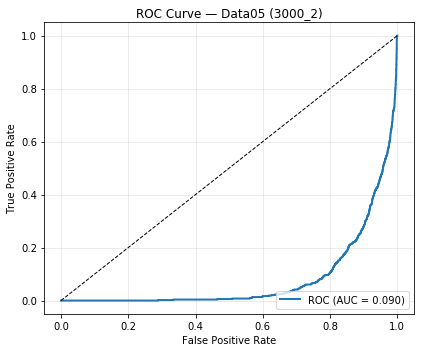

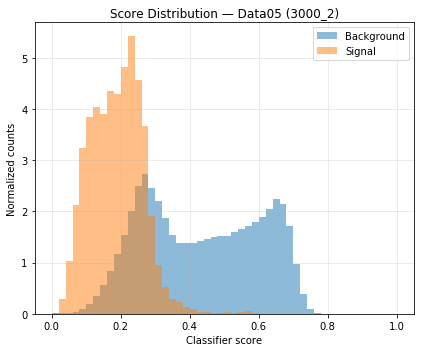


--- Signal mode: 3000_4 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.0879, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.0828, MaxSIC = 1.0005
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.0756, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.0807, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.0871, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1012, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.0930, MaxSIC = 

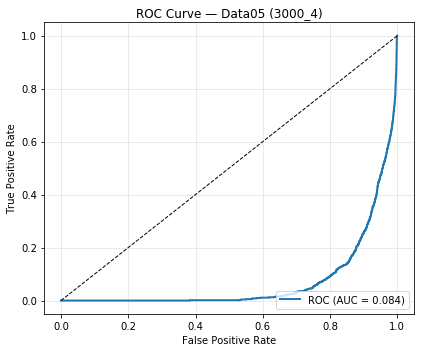

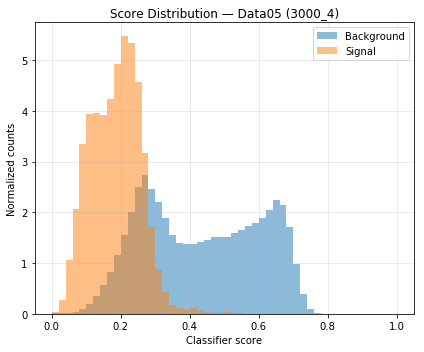


--- Signal mode: 3000_6 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.0886, MaxSIC = 1.0003
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.0835, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.0777, MaxSIC = 1.0005
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.0815, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.0865, MaxSIC = 1.0006
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1009, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.0936, MaxSIC = 

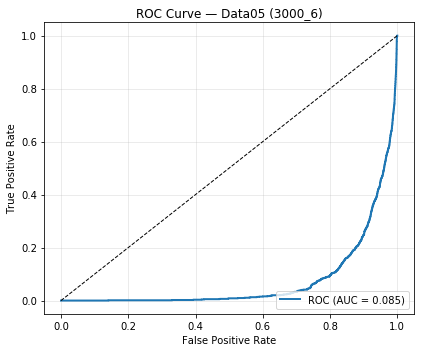

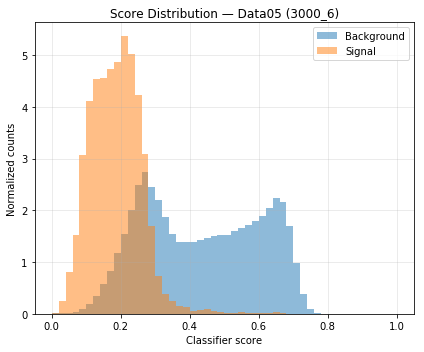


--- Signal mode: 3000_8 ---
   ▶️ Run 01: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run0.pt
      AUC = 0.0940, MaxSIC = 1.0004
   ▶️ Run 02: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run1.pt
      AUC = 0.0888, MaxSIC = 1.0003
   ▶️ Run 03: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run10.pt
      AUC = 0.0826, MaxSIC = 1.0006
   ▶️ Run 04: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run11.pt
      AUC = 0.0864, MaxSIC = 1.0003
   ▶️ Run 05: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run12.pt
      AUC = 0.0931, MaxSIC = 1.0005
   ▶️ Run 06: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run13.pt
      AUC = 0.1081, MaxSIC = 1.0002
   ▶️ Run 07: /ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr/model_reweight_SR_Data05_MC02_run14.pt
      AUC = 0.0985, MaxSIC = 

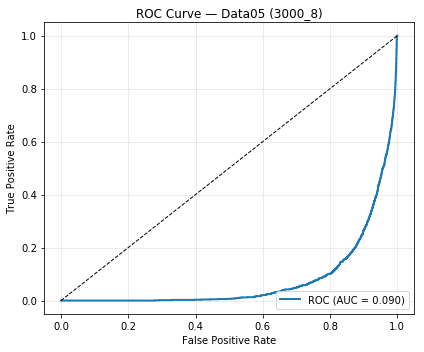

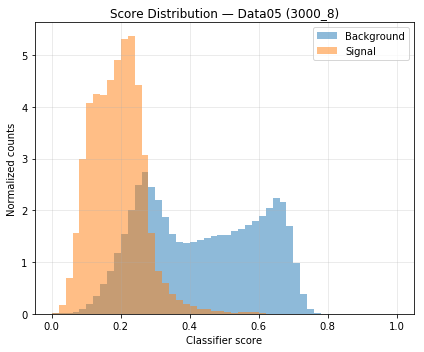


=== ✅ Evaluation complete ===


In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# -----------------------------
# Evaluation Loop
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = {}

n_context = 2
n_runs = 20

results = {}          # stores AUCs
maxsic_results = {}   # stores maxSIC values

n_context = 2  # skip first 2 columns → use last 5 features

for dataset, model_paths in reweight_models_paths.items():
    print(f"\n=== Evaluating models for {dataset} ===")

    results[dataset] = {}
    maxsic_results[dataset] = {}

    for mode in signal_modes:
        print(f"\n--- Signal mode: {mode} ---")

        model_aucs = []
        model_maxsics = []
        all_scores_sig = []
        all_scores_bkg = []
        # Loop over all 20 runs for this dataset
        for run in range(n_runs):
            if run >= len(model_paths):
                print(f"   ⚠️ Skipping run {run}, not enough models found.")
                continue

            model_path = model_paths[run]
            print(f"   ▶️ Run {run+1:02d}: {model_path}")

            # Load trained model
            NN = torch.load(model_path, map_location=device, weights_only=False)
            NN.to(device)
            NN.model.eval()

            # Prepare data
            input_x_test = x_test[mode][:, n_context:]  # numpy array (N, 5)
            input_y_test = y_test[mode]                 # numpy array (N,)

            # Evaluate model
            scores = NN.evaluation(input_x_test)
            scores = np.squeeze(scores)
            

            all_scores_sig.extend(scores[input_y_test == 1])
            all_scores_bkg.extend(scores[input_y_test == 0])
            # Compute AUC
            auc = roc_auc_score(input_y_test, scores)
            # if auc < 0.5:
            #     auc = 1.0 - auc

            # Compute SIC metrics
            fpr, tpr, _ = roc_curve(input_y_test, scores)
            fpr_nonzero = fpr[fpr != 0]
            tpr_nonzero = tpr[fpr != 0]

            rejection = 1.0 / fpr_nonzero
            sic = tpr_nonzero / np.sqrt(fpr_nonzero)

            # Calculate maxSIC above cutoff
            eps_bkg = 1.0 / ((0.4**2) * n_bkg)
            fpr_cutoff = fpr_nonzero > eps_bkg
            if np.any(fpr_cutoff):
                maxsic = np.nanmax(sic[fpr_cutoff])
            else:
                maxsic = np.nan

            print(f"      AUC = {auc:.4f}, MaxSIC = {maxsic:.4f}")

            model_aucs.append(auc)
            model_maxsics.append(maxsic)

        # Store per-mode results
        results[dataset][mode] = model_aucs
        maxsic_results[dataset][mode] = model_maxsics

        # -----------------------------
        # 📈 Plot ROC Curve (AUC)
        # -----------------------------
        plt.figure(figsize=(6, 5))
        mean_auc = np.mean(model_aucs)
        plt.plot(fpr, tpr, label=f"ROC (AUC = {mean_auc:.3f})", lw=2)
        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {dataset} ({mode})")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/roc_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

        # -----------------------------
        # 📊 Plot Score Distributions
        # -----------------------------
        plt.figure(figsize=(6, 5))
        plt.hist(all_scores_bkg, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:blue', label='Background', density=True)
        plt.hist(all_scores_sig, bins=50, range=(0, 1), histtype='stepfilled',
                 alpha=0.5, color='tab:orange', label='Signal', density=True)
        plt.xlabel("Classifier score")
        plt.ylabel("Normalized counts")
        plt.title(f"Score Distribution — {dataset} ({mode})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.savefig(f"{output_dir}/scores_{dataset}_{mode}.png", dpi=150)
        plt.show()
        plt.close()

print("\n=== ✅ Evaluation complete ===")

In [8]:
# from sklearn.metrics import roc_auc_score, roc_curve
# import numpy as np
# import matplotlib.pyplot as plt
# import torch
# from scipy import interp   # if SciPy not available, we'll use np.interp

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# n_runs = 20
# results = {}
# maxsic_results = {}

# # Common FPR grid to average ROC curves
# fpr_grid = np.linspace(0.0, 1.0, 1001)

# for dataset, model_paths in reweight_models_paths.items():
#     print(f"\n=== Evaluating models for {dataset} ===")
#     results[dataset] = {}
#     maxsic_results[dataset] = {}

#     for mode in signal_modes:
#         print(f"\n--- Signal mode: {mode} ---")
#         model_aucs = []
#         model_maxsics = []
#         all_scores_sig = []
#         all_scores_bkg = []

#         # store per-run ROC TPR interpolated on fpr_grid
#         tprs_interp = []

#         for run in range(n_runs):
#             if run >= len(model_paths):
#                 print(f"   ⚠️ Skipping run {run}, not enough models found.")
#                 continue

#             model_path = model_paths[run]
#             print(f"   ▶️ Run {run+1:02d}: {model_path}")

#             # load model - expect custom object with .model or evaluation method
#             NN = torch.load(model_path, map_location=device)
#             # try to move model to device safely
#             try:
#                 NN.to(device)
#             except Exception:
#                 # if NN is a plain state_dict or similar, user should adapt loader
#                 pass

#             # Ensure model is in eval
#             try:
#                 if hasattr(NN, "model"):
#                     NN.model.eval()
#                 else:
#                     NN.eval()
#             except Exception:
#                 pass

#             # Prepare data
#             input_x = x_test[mode][:, n_context:]  # numpy (N, nfeatures)
#             # --- FIX LABELS: 0 = background, 1 = signal
#             # previous code had them reversed; ensure here:
#             # background = first n_bkg entries, signal = next n_sig entries
#             n_bkg = mc_events["mc_events_sr"].shape[0]
#             n_sig = signal_samples[mode].shape[0]
#             y_true = np.concatenate((np.zeros(n_bkg, dtype=int), np.ones(n_sig, dtype=int)))

#             # Convert to torch tensor and send to device if NN expects tensors
#             x_tensor = torch.from_numpy(input_x.astype(np.float32))
#             x_tensor = x_tensor.to(device)

#             # Evaluate model safely
#             with torch.no_grad():
#                 # Prefer to call NN.evaluation if available (your wrapper)
#                 if hasattr(NN, "evaluation"):
#                     # ensure evaluation accepts numpy or tensor - if it expects numpy, convert back
#                     try:
#                         scores = NN.evaluation(x_tensor)
#                     except Exception:
#                         # fallback to numpy input
#                         scores = NN.evaluation(input_x)
#                 else:
#                     # attempt to run NN.model directly
#                     if hasattr(NN, "model"):
#                         out = NN.model(x_tensor)
#                     else:
#                         out = NN(x_tensor)
#                     # handle logits / single output
#                     out = out.detach().cpu().numpy()
#                     scores = out.squeeze()

#             scores = np.asarray(scores).squeeze()
#             if scores.ndim != 1:
#                 # if shape (N,2) with class probabilities, take positive class
#                 if scores.shape[1] == 2:
#                     scores = scores[:, 1]
#                 else:
#                     scores = scores.ravel()

#             # Collect per-class scores (now labels are correct: 0=bkg,1=sig)
#             all_scores_bkg.extend(scores[y_true == 0].tolist())
#             all_scores_sig.extend(scores[y_true == 1].tolist())

#             # Compute AUC
#             try:
#                 auc = roc_auc_score(y_true, scores)
#             except Exception as e:
#                 print("   ❗ roc_auc_score failed:", e)
#                 auc = np.nan

#             # Compute ROC for this run
#             fpr, tpr, thr = roc_curve(y_true, scores)

#             # Interpolate tpr on common fpr grid for averaging
#             # using numpy interp (monotonic fpr)
#             tpr_interp = np.interp(fpr_grid, fpr, tpr)
#             tprs_interp.append(tpr_interp)

#             # compute SIC avoiding fpr==0
#             fpr_nonzero_mask = fpr > 0
#             fpr_nonzero = fpr[fpr_nonzero_mask]
#             tpr_nonzero = tpr[fpr_nonzero_mask]
#             # avoid extremely small fpr leading to massive sic; set floor
#             fpr_floor = 1e-12
#             fpr_nonzero = np.clip(fpr_nonzero, fpr_floor, None)
#             sic = tpr_nonzero / np.sqrt(fpr_nonzero)

#             # apply your cutoff (keep previous formula)
#             eps_bkg = 1.0 / ((0.4**2) * n_bkg)
#             mask_cut = fpr_nonzero > eps_bkg
#             maxsic = np.nan
#             if np.any(mask_cut):
#                 maxsic = np.nanmax(sic[mask_cut])

#             print(f"      AUC = {auc:.4f}, MaxSIC = {maxsic:.4f}")

#             model_aucs.append(auc)
#             model_maxsics.append(maxsic)

#         # store results
#         results[dataset][mode] = model_aucs
#         maxsic_results[dataset][mode] = model_maxsics

#         # compute mean ROC from interpolated TPRs
#         if len(tprs_interp) > 0:
#             mean_tpr = np.mean(np.vstack(tprs_interp), axis=0)
#         else:
#             mean_tpr = np.zeros_like(fpr_grid)

#         # Plot mean ROC curve (averaged over runs) and also a light band
#         plt.figure(figsize=(6,5))
#         mean_auc = np.nanmean(model_aucs) if len(model_aucs)>0 else np.nan
#         plt.plot(fpr_grid, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.3f})", lw=2)
#         # optionally plot individual runs lightly
#         for tpr_i in tprs_interp:
#             plt.plot(fpr_grid, tpr_i, color='gray', alpha=0.15, lw=0.8)
#         plt.plot([0,1],[0,1],'k--', lw=1)
#         plt.xlabel("False Positive Rate")
#         plt.ylabel("True Positive Rate")
#         plt.title(f"ROC Curve — {dataset} ({mode})")
#         plt.legend(loc="lower right")
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.show()
#         plt.close()

#         # Score distributions (ensure labels now correct)
#         plt.figure(figsize=(6,5))
#         plt.hist(all_scores_bkg, bins=50, range=(0,1), histtype='stepfilled', alpha=0.5, label='Background', density=True)
#         plt.hist(all_scores_sig, bins=50, range=(0,1), histtype='stepfilled', alpha=0.5, label='Signal', density=True)
#         plt.xlabel("Classifier score")
#         plt.ylabel("Normalized counts")
#         plt.title(f"Score Distribution — {dataset} ({mode})")
#         plt.legend()
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.show()
#         plt.close()

# print("\n=== ✅ Evaluation complete ===")

In [9]:
# -----------------------------
# Summary statistics
# -----------------------------
for dataset in results.keys():
    print(f"\n--- Dataset: {dataset} ---")
    for mode in signal_modes:
        aucs = np.array(results[dataset][mode])
        maxsics = np.array(maxsic_results[dataset][mode])

        mean_auc = np.nanmean(aucs)
        mean_maxsic = np.nanmean(maxsics)

        print(f"Mode {mode}:")
        print(f"   Mean AUC   = {mean_auc:.4f}")
        print(f"   Mean MaxSIC = {mean_maxsic:.4f}")


--- Dataset: Data01 ---
Mode 1000_2:
   Mean AUC   = 0.4077
   Mean MaxSIC = 1.0014
Mode 1000_4:
   Mean AUC   = 0.3423
   Mean MaxSIC = 1.0007
Mode 1000_6:
   Mean AUC   = 0.4068
   Mean MaxSIC = 1.0088
Mode 1000_8:
   Mean AUC   = 0.3958
   Mean MaxSIC = 1.0015
Mode 2000_2:
   Mean AUC   = 0.1464
   Mean MaxSIC = 1.0008
Mode 2000_4:
   Mean AUC   = 0.1443
   Mean MaxSIC = 1.0008
Mode 2000_6:
   Mean AUC   = 0.1444
   Mean MaxSIC = 1.0007
Mode 2000_8:
   Mean AUC   = 0.1512
   Mean MaxSIC = 1.0007
Mode 3000_2:
   Mean AUC   = 0.0896
   Mean MaxSIC = 1.0004
Mode 3000_4:
   Mean AUC   = 0.0835
   Mean MaxSIC = 1.0004
Mode 3000_6:
   Mean AUC   = 0.0844
   Mean MaxSIC = 1.0004
Mode 3000_8:
   Mean AUC   = 0.0898
   Mean MaxSIC = 1.0004

--- Dataset: Data02 ---
Mode 1000_2:
   Mean AUC   = 0.4076
   Mean MaxSIC = 1.0014
Mode 1000_4:
   Mean AUC   = 0.3429
   Mean MaxSIC = 1.0007
Mode 1000_6:
   Mean AUC   = 0.4068
   Mean MaxSIC = 1.0089
Mode 1000_8:
   Mean AUC   = 0.3961
   Mean MaxSIC